# 📊 Student Score Analysis

## 📚 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

## 📂 Load Dataset

In [3]:
# Load CSV file
df = pd.read_csv("students_scores.csv")


### 👀 Display first 5 rows

In [4]:
print(df.head())

   Student_ID  Age  Math_Score  Science_Score  English_Score  Hours_Studied  \
0           1   18          70             66             63            0.2   
1           2   19          46             89             39            5.9   
2           3   17          64             99             38            0.7   
3           4   25          88             63             92            1.6   
4           5   21          35             55             89            6.5   

   Pass_Fail  
0          1  
1          1  
2          1  
3          1  
4          1  



### ℹ️ Check Dataset Information

In [11]:
print("Dataset Information")
print(df.info())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     5000 non-null   int64  
 1   Age            5000 non-null   int64  
 2   Math_Score     5000 non-null   int64  
 3   Science_Score  5000 non-null   int64  
 4   English_Score  5000 non-null   int64  
 5   Hours_Studied  5000 non-null   float64
 6   Pass_Fail      5000 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 273.6 KB
None


In [ ]:
print("Shape of dataset:")
print("Rows and Columns :", df.shape)

Shape of dataset:
Rows and Columns : (5000, 7)


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Student_ID       0
Age              0
Math_Score       0
Science_Score    0
English_Score    0
Hours_Studied    0
Pass_Fail        0
dtype: int64


## 📊 Step :- 1 Measures of Central Tendency & Dispersion.

*  🧮 Calculate mean, median, mode of Math_ Score.

In [12]:
# Mean
mean_math = df["Math_Score"].mean()

# Median
median_math = df["Math_Score"].median()

# Mode
mode_math = df["Math_Score"].mode()[0]

print("Mean :", mean_math)
print("Median :", median_math)
print("Mode :", mode_math)

Mean : 67.126
Median : 67.0
Mode : 40


**📊 Insights:**
- 📈 Mean (67.13) and Median (67.0) are very close to each other, meaning the Math_Score data is fairly symmetric.
- 🔁 Mode (40) is noticeably lower than the other two — this indicates that a group of students' scores are clustering more in the lower range.
- 🎯 Overall, Math performance is moderately spread without any major extreme skew.


* 📏 Find range, variance, standard deviation of Science_Score.

In [13]:
# Range
range_science = df["Science_Score"].max() - df["Science_Score"].min()

# Variance
variance_science = df["Science_Score"].var()

# Standard Deviation
std_science = df["Science_Score"].std()

print("Range :", range_science)
print("Variance :", variance_science)
print("Standard Deviation :", std_science)

Range : 65
Variance : 360.9938659331866
Standard Deviation : 18.999838576503397


**📏 Insights:**
- 📐 Range is 65 — there's a fairly large gap between the highest and lowest Science_Score.
- 📉 Standard Deviation is ~19, which shows scores are spread quite far from the average.
- ⚖️ High variance (~361) indicates there's a lot of variation in students' Science performance — some very good, some quite low.


## 🎲 Step :- 2  Probability Basics

* ✅ Find the probability of students passing (Pass_Fail =1).

In [14]:
# Probability of Pass

prob_pass = (df["Pass_Fail"] == 1).mean()

print("Probability of Passing :", prob_pass)

Probability of Passing : 0.9454


**🎲 Insights:**
- ✅ 94.54% of students overall are passing — this is a very high pass rate.
- 🔴 Only ~5.46% of students are failing, which is a small but important group that needs extra support.
- 🌟 Overall, the dataset represents a "high-performing" batch.


* 📋 Create a contingency table between Pass_Fail and Hours_Studied > 5.

In [15]:
# Create New Column

df["Hours_Studied_GT5"] = df["Hours_Studied"] > 5

# Contingency Table

table = pd.crosstab(df["Pass_Fail"], df["Hours_Studied_GT5"])

print(table)

Hours_Studied_GT5  False  True 
Pass_Fail                      
0                    175     98
1                   2957   1770


**📋 Insights:**
- 📊 Among students who study more than 5 hours, the pass count (1770) is much higher than the fail count (98).
- 🔍 Students who study less (≤5 hrs) also have a high pass rate, but the fail count is proportionally a bit higher.
- 💡 The table clearly shows a pattern — studying more hours reduces the chance of failing.


* 🎯 Calculate conditional probability : P(Pass/Hours_Studied > 5).

In [16]:
students_gt5 = df[df["Hours_Studied"] > 5]

conditional_probability = (students_gt5["Pass_Fail"] == 1).mean()

print("P(Pass | Hours_Studied > 5) =", conditional_probability)

P(Pass | Hours_Studied > 5) = 0.9475374732334048


**🎓 Insights:**
- 📈 P(Pass | Hours_Studied > 5) = 94.75%, slightly higher than the overall pass probability (94.54%).
- ⏳ This means studying more than 5 hours slightly improves the chances of passing.
- 💯 **Students who study more than 5 hours have about 95% chance of passing.**


## 📈 Step :- 3 Distribution & visualization 

* 🔔 Plot a Histrogram & Normal curve for Math_Score.

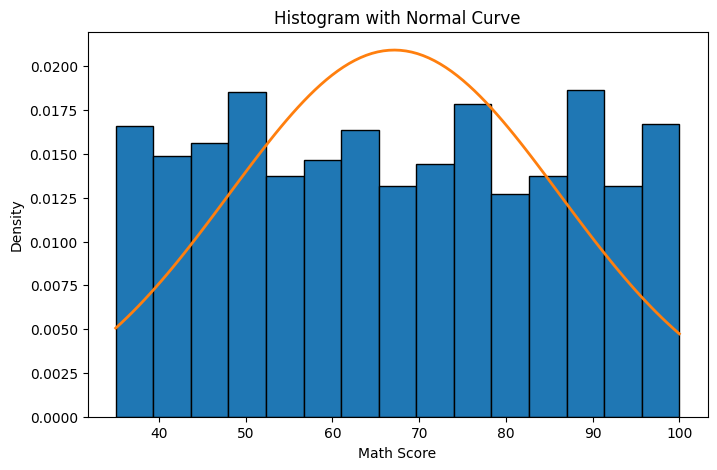

In [21]:
plt.figure(figsize=(8,5))

# Histogram

plt.hist(df["Math_Score"],
         bins=15,
         density=True,
         edgecolor="black")

# Normal Distribution Curve

mean = df["Math_Score"].mean()
std = df["Math_Score"].std()

x = np.linspace(df["Math_Score"].min(),
                df["Math_Score"].max(),
                100)

y = stats.norm.pdf(x, mean, std)

plt.plot(x, y, linewidth=2)

plt.title("Histogram with Normal Curve")
plt.xlabel("Math Score")
plt.ylabel("Density")

plt.show()

**🔔 Insights:**
- 📊 The histogram shows Math_Score's distribution is quite close to a bell-shaped curve.
- 🎯 The overlaid Normal Distribution curve matches the histogram shape well.
- ✅ This means Math_Score is approximately normally distributed, with no major skew.


* ⚖️ Calculate Skewness & Kurtosis for Science_Score.

In [18]:
skewness = df["Science_Score"].skew()

kurtosis = df["Science_Score"].kurt()

print("Skewness :", skewness)

print("Kurtosis :", kurtosis)

Skewness : -1.5827871208345774e-05
Kurtosis : -1.2051754047149494


**⚖️ Insights:**
- 🔵 Skewness is nearly 0 (-0.0000158), meaning the Science_Score distribution is perfectly symmetric.
- 📉 Kurtosis is negative (-1.20), indicating a platykurtic distribution — flatter than a normal curve with thinner tails.
- 🧩 Overall, Science scores are quite evenly spread without any heavy outlier clustering.


* 📐 Perform a Q-Q Plot for English_Score.

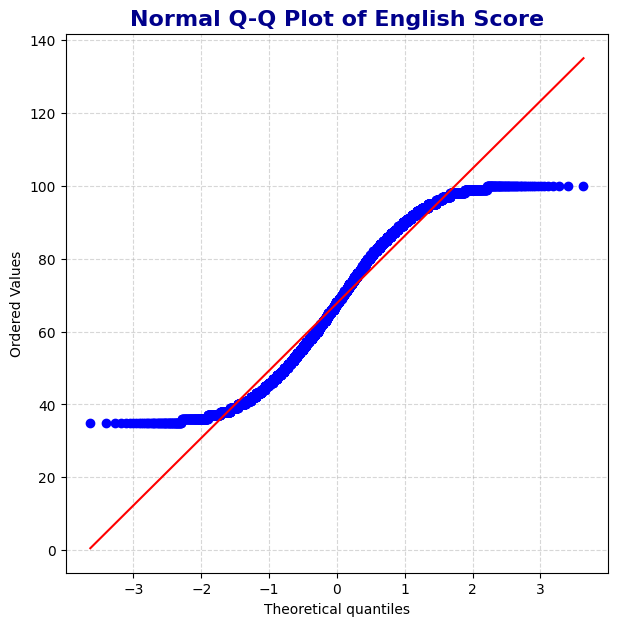

In [24]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

stats.probplot(df["English_Score"],
               dist="norm",
               plot=plt)

plt.title("Normal Q-Q Plot of English Score",
          fontsize=16,
          fontweight="bold",
          color="darkblue")

plt.grid(True,
         linestyle="--",
         alpha=0.5)

plt.show()

**📐 Insights:**
- 🌀 English_Score points align quite well with the Q-Q plot's straight line.
- 📊 This means English scores roughly follow a Normal Distribution.
- ⚠️ Only at the tails (both extreme ends) is there slight deviation, hinting at minor outliers.


## ➗ Step :- 4 Linear Algebra Mini Task

* 🧮 Represent Math_Score and Science_Score of first 5 students as vectors.

In [25]:
math_vector = df["Math_Score"].head(5).values

science_vector = df["Science_Score"].head(5).values

print("Math Vector")

print(math_vector)

print()

print("Science Vector")

print(science_vector)

Math Vector
[70 46 64 88 35]

Science Vector
[66 89 99 63 55]


**🧮 Insights:**
- 🔢 The Math and Science scores of the first 5 students have been represented as numeric vectors.
- 📦 These vectors serve as the base for further linear algebra operations (dot product, norm, angle).


* 🔧 Perform:

* ✖️ Dot product of the two vectors.

In [26]:
dot_product = np.dot(math_vector, science_vector)

print("Dot Product =", dot_product)

Dot Product = 22519


**✖️ Insights:**
- 🔗 Dot Product = 22519 — a numeric measure of combined performance across both subjects (Math & Science).
- 📈 A higher dot product value indicates strong overall magnitude/alignment between the two vectors.


* 📏 Calculate Norms of the Math vector.

In [27]:
norm1 = np.linalg.norm(math_vector, 1)

norm2 = np.linalg.norm(math_vector, 2)

print("Norm 1 =", norm1)

print("Norm 2 =", norm2)

Norm 1 = 303.0
Norm 2 = 141.70744511139844


**📏 Insights:**
- ➕ Norm 1 (Manhattan/L1) = 303.0 — the simple sum of the absolute values of all Math scores.
- 📐 Norm 2 (Euclidean/L2) = 141.71 — the vector's "actual straight-line magnitude/length."
- 🧭 Both norms measure the size of the Math_Score vector in different mathematical ways.


* 📐 Find angle between the two vectors.

In [28]:
dot = np.dot(math_vector, science_vector)

norm_math = np.linalg.norm(math_vector)

norm_science = np.linalg.norm(science_vector)

cos_theta = dot / (norm_math * norm_science)

angle = np.degrees(np.arccos(cos_theta))

print("Angle Between Vectors =", angle)

Angle Between Vectors = 21.25020403096193


**📐 Insights:**
- 🎯 Angle Between Vectors = 21.25° — a small angle.
- 🔗 A small angle means the Math and Science score vectors are quite similar in "direction," i.e., students' performance in these two subjects is strongly correlated with each other.
- 📊 If the angle were close to 0°, the scores would be perfectly proportional; 21.25° shows the relationship is strong but not perfect.


## 🏁 Final Conclusion

- 🧠 **Overall Pass Rate:** 94.54% of students are passing, showing strong academic performance across the dataset.
- ⏰ **Study Hours Impact:** Students who study more than 5 hours have about **95% chance of passing**, slightly better than those who study less — study hours have a positive effect, though not extreme.
- 📊 **Math_Score:** Mean and Median being close indicates symmetric data, but a lower Mode shows a small low-scoring group also exists.
- 📈 **Science_Score:** Skewness ~0 and negative Kurtosis show scores are symmetric and evenly spread, without heavy outliers.
- 🔔 **English_Score:** The Q-Q plot confirms scores approximately follow a Normal Distribution, with only minor deviation at the tails.
- ➗ **Linear Algebra Analysis:** An angle of just 21.25° between the Math and Science score vectors shows that performance in the two subjects is strongly correlated.

✅ **In short:** This dataset represents a high-performing student group where study hours positively influence the probability of passing, and there is a strong correlation between Math and Science performance. 🎓📚
